# Student Academic Assistant: A Conversational AI Approach Using GPT-2 and BERT
**1. Taghreed Alzahrani - 443007366**  
**2. Rawan Alharthi - 444001029**  
**3. Mashael Abdali - 444001062**  
**4. Jana Metub Alhakami - 444005086**  
**5. Ghadeer Aseeri - 444004332**

In [ ]:
# Upload orginal dataset
from google.colab import files
uploaded = files.upload()

**Create custome QA dataset**

In [ ]:
import pandas as pd

# Load the original dataset
file_path = "/content/course-catalog.csv"
df = pd.read_csv(file_path)

# Display basic data
print(df.head())

# Create the new dataset
questions = []
answers = []
categories = []

# Generate questions, answers, and categories
for index, row in df.iterrows():

    # Question: What is the name of the course?
    questions.append(f"What is the name of the course {row['Subject']} {row['Number']}?")
    answers.append(row['Name'])
    categories.append("Course Name")

    # Question: What is the course description?
    questions.append(f"What is the description of the course {row['Subject']} {row['Number']}?")
    answers.append(row['Description'])
    categories.append("Course Description")

    # Question: How many credit hours?
    questions.append(f"How many credit hours is the course {row['Subject']} {row['Number']}?")
    answers.append(row['Credit Hours'])
    categories.append("Credit Hours")

    # Question: What department does the course belong to?
    questions.append(f"What subject does the course {row['Subject']} {row['Number']} belong to?")
    answers.append(row['Subject'])
    categories.append("Subject")

# Create the new DataFrame
new_dataset = pd.DataFrame({
    "question": questions,
    "answer": answers,
    "category": categories
})

# Check for missing values
missing_values = new_dataset.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])

# Drop rows with missing values
new_dataset = new_dataset.dropna()

# Save the new dataset
output_path = "/content/new_qa_dataset.csv"
new_dataset.to_csv(output_path, index=False)
print(f"New dataset saved to {output_path}")

# Display the first 5 rows of the new dataset
print(new_dataset.head())

   Year  Term YearTerm Subject  Number                          Name  \
0  2024  Fall  2024-fa     AAS     100  Intro Asian American Studies   
1  2024  Fall  2024-fa     AAS     100  Intro Asian American Studies   
2  2024  Fall  2024-fa     AAS     100  Intro Asian American Studies   
3  2024  Fall  2024-fa     AAS     100  Intro Asian American Studies   
4  2024  Fall  2024-fa     AAS     100  Intro Asian American Studies   

                                         Description Credit Hours  \
0  Interdisciplinary introduction to the basic co...     3 hours.   
1  Interdisciplinary introduction to the basic co...     3 hours.   
2  Interdisciplinary introduction to the basic co...     3 hours.   
3  Interdisciplinary introduction to the basic co...     3 hours.   
4  Interdisciplinary introduction to the basic co...     3 hours.   

  Section Info                                  Degree Attributes  ...  \
0          NaN  Social & Beh Sci - Soc Sci, and Cultural Studi...  ...   
1   

In [ ]:
# Print the number of rows in the new dataset
print(f"Number of rows in the new dataset: {len(new_dataset)}")

# Alternative using shape
print(f"Number of rows in the new dataset: {new_dataset.shape[0]}")

Number of rows in the new dataset: 51959
Number of rows in the new dataset: 51959


# **Fine-tune with BERT**

                                               question  \
47240    What is the description of the course SOC 479?   
28968     What is the description of the course IS 584?   
21413     How many credit hours is the course EPSY 584?   
13270       How many credit hours is the course CS 101?   
24202  What subject does the course GLBL 100 belong to?   

                                                  answer            category  
47240  Examination of the social and political organi...  Course Description  
28968  Variety of newly developed and advanced topics...  Course Description  
21413                                           4 hours.        Credit Hours  
13270                                           3 hours.        Credit Hours  
24202                                               GLBL             Subject  
label_to_answer dictionary saved to /content/label_to_answer.json


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Number of unique answers: 5296
Epoch 1, Training Loss: 6.1774, Validation Accuracy: 27.20%
Epoch 2, Training Loss: 4.8232, Validation Accuracy: 38.61%


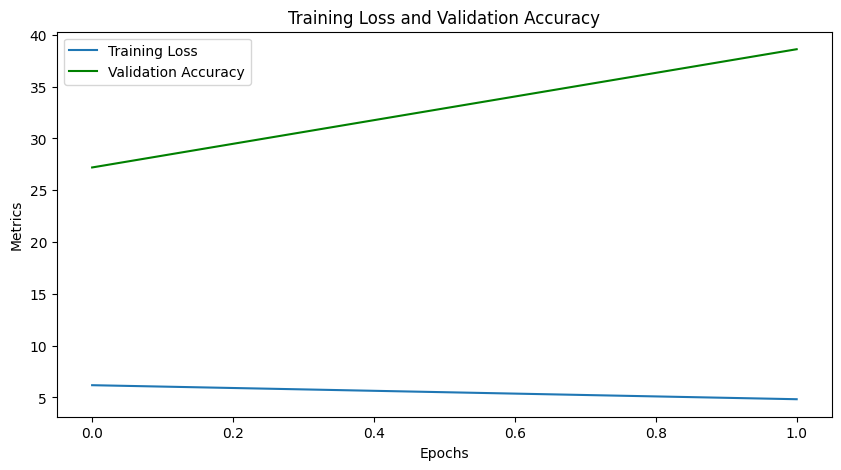

Question: What is the description of the course IS 584?
Predicted Answer: THEA


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load the dataset
file_path = "/content/new_qa_dataset.csv"
df = pd.read_csv(file_path)
df = df.sample(n=23000, random_state=42)
print(df.head())

# Clean text and replace missing values
df['question'] = df['question'].fillna("").astype(str)
df['answer'] = df['answer'].fillna("").astype(str)

# Convert answers to numerical labels (encoding answers)
df['label'] = df['answer'].astype('category').cat.codes
label_to_answer = dict(enumerate(df['answer'].astype('category').cat.categories))

label_to_answer_path = "/content/label_to_answer.json"
with open(label_to_answer_path, "w") as f:
    json.dump(label_to_answer, f)
print(f"label_to_answer dictionary saved to {label_to_answer_path}")

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['question'], df['label'], test_size=0.2, random_state=42
)

# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Convert text to BERT inputs
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")
val_encodings = tokenizer(val_texts.tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")

# Create TensorDataset
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], torch.tensor(train_labels.tolist()))
val_dataset = TensorDataset(val_encodings['input_ids'], val_encodings['attention_mask'], torch.tensor(val_labels.tolist()))

# Prepare DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Load the model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=df['label'].nunique())
print("Number of unique answers:", df['label'].nunique())

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=3e-5)

# Model evaluation function
def evaluate_model(dataloader):
    """
    دالة لتقييم النموذج على بيانات التحقق.
    """
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = batch
            outputs = model(input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
    return correct / total

# Train the model
train_loss_values = []
val_accuracy_values = []

for epoch in range(2):  # Train for 2 epochs
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids, attention_mask, labels = batch
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Calculate average loss
    avg_train_loss = total_loss / len(train_loader)
    train_loss_values.append(avg_train_loss)

    # Evaluate model on validation data
    val_accuracy = evaluate_model(val_loader)
    val_accuracy_values.append(val_accuracy * 100)

    # Print results
    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss:.4f}, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Plot loss and accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label="Training Loss")
plt.plot(val_accuracy_values, label="Validation Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Metrics")
plt.title("Training Loss and Validation Accuracy")
plt.legend()
plt.show()

# Function to predict the answer
def predict_answer(question):
    model.eval()
    encoded = tokenizer(question, truncation=True, padding=True, max_length=512, return_tensors="pt")
    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
    return label_to_answer[prediction]

# Test the model with a question
user_question = "What is the description of the course IS 584?"
predicted_answer = predict_answer(user_question)
print(f"Question: {user_question}")
print(f"Predicted Answer: {predicted_answer}")

**Save Model**

In [ ]:
# Save the model and tokenizer
model_save_path = "/content/saved_model_bert"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model and tokenizer saved to {model_save_path}")

#  Save fine-tuned model as zip
!zip -r saved_model_bert.zip ./saved_model_bert
from google.colab import files
#files.download("saved_model_bert.zip")

Model and tokenizer saved to /content/saved_model_bert
  adding: saved_model_bert/ (stored 0%)
  adding: saved_model_bert/config.json (deflated 79%)
  adding: saved_model_bert/vocab.txt (deflated 53%)
  adding: saved_model_bert/tokenizer_config.json (deflated 75%)
  adding: saved_model_bert/model.safetensors (deflated 7%)
  adding: saved_model_bert/special_tokens_map.json (deflated 42%)


**Test bert model**

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch
import json

# Load the saved model and tokenizer
model_save_path = "/content/saved_model_bert"
loaded_model = BertForSequenceClassification.from_pretrained(model_save_path)
loaded_tokenizer = BertTokenizer.from_pretrained(model_save_path)

# Load the answer dictionary from the JSON file
label_to_answer_path = "/content/label_to_answer.json"  # Path to the saved dictionary file
with open(label_to_answer_path, "r") as f:
    label_to_answer = json.load(f)

# Convert keys from strings to integers (since JSON stores keys as strings)
label_to_answer = {int(k): v for k, v in label_to_answer.items()}

# Create a dictionary to store user-corrected answers
corrected_answers = {}

print("تم تحميل النموذج، التوكنايزر، وقاموس الإجابات بنجاح!")

# Define a function to predict the answer
def predict_saved_model(question, model, tokenizer, label_to_answer, corrected_answers):
    # Check if the question has a previously corrected answer
    if question in corrected_answers:
        return corrected_answers[question]

    # Set the model to evaluation mode
    model.eval()

    # Convert the question into BERT input format
    encoded = tokenizer(question, truncation=True, padding=True, max_length=512, return_tensors="pt")
    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]

    # Predict the answer without computing gradients (for efficiency)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=-1).item()

    # Return the corresponding answer for the predicted label
    return label_to_answer[prediction]

# Interactive loop to test the model
print("Test the saved. Type 'exit' to exit.")
while True:
    # Prompt the user for a question
    user_question = input("Enter your question: ").strip()
    if user_question.lower() == "exit":
        print("Exiting. Goodbye!")
        break

    # Predict the answer
    predicted_answer = predict_saved_model(user_question, loaded_model, loaded_tokenizer, label_to_answer, corrected_answers)
    print(f"Question: {user_question}")
    print(f"Predicted Answer: {predicted_answer}")

    # Ask the user if the answer is correct
    feedback = input("Is this answer correct? (Yes/No): ").strip().lower()

    if feedback == "no":
        # Ask the user for the correct answer
        correct_answer = input("Please enter the correct answer: ").strip()
        # Update the corrected answers dictionary
        corrected_answers[user_question] = correct_answer
        print("The correct answer has been updated.")
    else:
        print("The answer has been accepted.")

    # Allow the user to ask another question or exit
    print("\nYou can now ask another question or type 'exit' to exit.")

تم تحميل النموذج، التوكنايزر، وقاموس الإجابات بنجاح!
Test the saved. Type 'exit' to exit.
Enter your question: How many credit hours is the course ADV 250?
Question: How many credit hours is the course ADV 250?
Predicted Answer: 3 hours.
Is this answer correct? (Yes/No): yes
The answer has been accepted.

You can now ask another question or type 'exit' to exit.
Enter your question: What subject does the course ADV 250 belong to?
Question: What subject does the course ADV 250 belong to?
Predicted Answer: HIST
Is this answer correct? (Yes/No): no
Please enter the correct answer: ADV
The correct answer has been updated.

You can now ask another question or type 'exit' to exit.
Enter your question: What subject does the course ADV 250 belong to?
Question: What subject does the course ADV 250 belong to?
Predicted Answer: ADV
Is this answer correct? (Yes/No): yes
The answer has been accepted.

You can now ask another question or type 'exit' to exit.
Enter your question: What is the descripti

# **Fine-tune with GPT2**

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("new_qa_dataset.csv")

# Sample 23,000 rows from the dataset
df = df.sample(n=23000, random_state=42).reset_index(drop=True)

# Format the dataset
df["input_text"] = df.apply(lambda row: f"Question: {row['question']} Answer: {row['answer']}", axis=1)

# Initialize the model and tokenizer
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # Set padding token

model = GPT2LMHeadModel.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

# Class for processing inputs to be compatible with GPT-2
class QADataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input_text = self.data[idx]
        encoded = self.tokenizer(
            input_text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        input_ids = encoded["input_ids"].squeeze()
        attention_mask = encoded["attention_mask"].squeeze()
        return input_ids, attention_mask

# Prepare dataset and dataloader
train_texts = df["input_text"].tolist()
train_dataset = QADataset(train_texts, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Optimizer and device
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
epochs = 3
model.train()
epoch_losses = []
epoch_accuracies = []

for epoch in range(epochs):
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0

    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        input_ids, attention_mask = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
        loss = outputs.loss
        logits = outputs.logits

        # Calculate token-level accuracy
        predictions = torch.argmax(logits, dim=-1)
        correct_predictions += (predictions == input_ids).sum().item()
        total_predictions += torch.numel(input_ids)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        # Update progress bar
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    # Calculate and store metrics for the epoch
    epoch_accuracy = correct_predictions / total_predictions
    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_accuracy)

    # Print epoch metrics
    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

# Print final training accuracy
final_accuracy = epoch_accuracies[-1]
print(f"Final Training Accuracy: {final_accuracy:.2%}")

# Save the trained model
model.save_pretrained("fine_tuned_gpt2")
tokenizer.save_pretrained("fine_tuned_gpt2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Epoch 2: 100%|██████████| 2875/2875 [15:18<00:00,  3.13it/s, loss=0.178]


Epoch 2 Loss: 944.5587, Accuracy: 0.7261


Epoch 3: 100%|██████████| 2875/2875 [15:18<00:00,  3.13it/s, loss=0.222]


Epoch 3 Loss: 767.8806, Accuracy: 0.7261
Final Training Accuracy: 72.61%


('fine_tuned_gpt2/tokenizer_config.json',
 'fine_tuned_gpt2/special_tokens_map.json',
 'fine_tuned_gpt2/vocab.json',
 'fine_tuned_gpt2/merges.txt',
 'fine_tuned_gpt2/added_tokens.json')

In [ ]:
#  Save fine-tuned model as zip
!zip -r fine_tuned_gpt2.zip ./fine_tuned_gpt2
from google.colab import files

  adding: fine_tuned_gpt2/ (stored 0%)
  adding: fine_tuned_gpt2/config.json (deflated 51%)
  adding: fine_tuned_gpt2/merges.txt (deflated 53%)
  adding: fine_tuned_gpt2/generation_config.json (deflated 24%)
  adding: fine_tuned_gpt2/vocab.json (deflated 68%)
  adding: fine_tuned_gpt2/tokenizer_config.json (deflated 56%)
  adding: fine_tuned_gpt2/model.safetensors (deflated 7%)
  adding: fine_tuned_gpt2/special_tokens_map.json (deflated 74%)


**Visulaize traning accuracy**

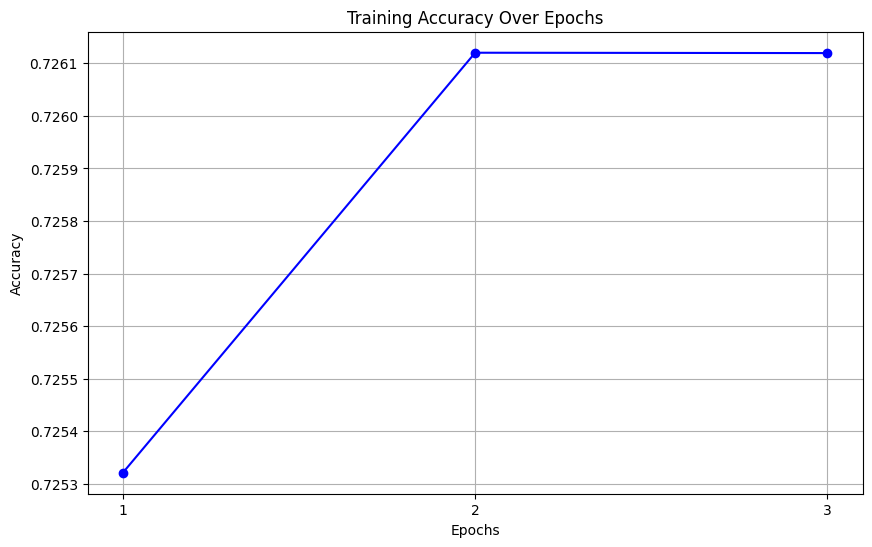

In [ ]:
import matplotlib.pyplot as plt

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_accuracies, marker='o', linestyle='-', color='b')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1, epochs + 1))
plt.grid()
plt.show()

**Visulaize traning loss**

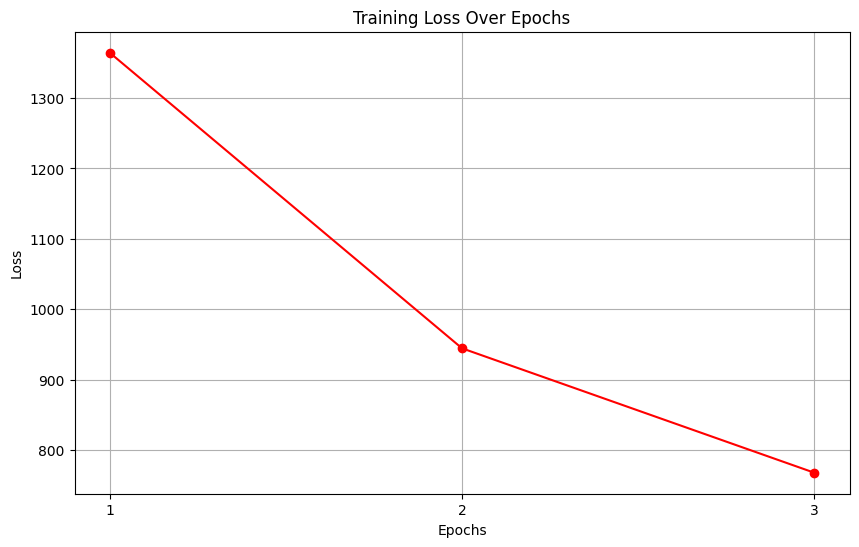

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-', color='r')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(1, epochs + 1))
plt.grid()
plt.show()

**Test model with questions**

In [ ]:
import json
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch
import os

# Load the fine-tuned model and tokenizer
model_name = "fine_tuned_gpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# Ensure pad_token is set
tokenizer.pad_token = tokenizer.eos_token

# Move model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# File to store corrected answers
CORRECTED_ANSWERS_FILE = "corrected_answers.json"

# Load corrected answers from file if it exists
if os.path.exists(CORRECTED_ANSWERS_FILE):
    with open(CORRECTED_ANSWERS_FILE, "r") as f:
        corrected_answers = json.load(f)
else:
    corrected_answers = {}

# Function to generate answers
def generate_answer(question):
    # Check if the question has a corrected answer
    if question in corrected_answers:
        return corrected_answers[question]

    input_text = f"Question: {question} Answer:"
    input_ids = tokenizer.encode(input_text, return_tensors="pt", truncation=True, max_length=128)
    input_ids = input_ids.to(device)  # To ensure input_ids are on the same device as the model

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_length=128,
            num_beams=5,
            early_stopping=True,
            pad_token_id=tokenizer.eos_token_id  # Explicitly set pad token
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    clean_ans = clean_answer(answer, question)
    return clean_ans

def clean_answer(answer, question):
    # Remove question text from the answer
    return answer.replace(f"Question: {question} Answer:", "").strip()

def update_answer(question, correct_answer):
    # Store the corrected answer in the dictionary
    corrected_answers[question] = correct_answer
    # Save the updated dictionary to the file
    with open(CORRECTED_ANSWERS_FILE, "w") as f:
        json.dump(corrected_answers, f)
    print(f"Updated answer for question: {question}")

# Interactive loop for user to ask questions and provide feedback
while True:
    question = input("Enter your question (or type 'exit' to quit): ")
    if question.lower() == 'exit':
        break

    answer = generate_answer(question)
    print(f"Answer: {answer}")

    feedback = input("Was the answer correct? (yes/no): ").strip().lower()
    if feedback == 'no':
        correct_answer = input("Please provide the correct answer: ").strip()
        update_answer(question, correct_answer)
    elif feedback == 'yes':
        print("Great! Let me know if you have more questions.")
    else:
        print("Invalid feedback. Please type 'yes' or 'no'.")

Enter your question (or type 'exit' to quit): How many credit hours is the course ADV 250?


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Answer: 3 hours.
Was the answer correct? (yes/no): yes
Great! Let me know if you have more questions.
Enter your question (or type 'exit' to quit): What subject does the course ADV 250 belong to?
Answer: ADV
Was the answer correct? (yes/no): yes
Great! Let me know if you have more questions.
Enter your question (or type 'exit' to quit): What is the description of the course ADV 250?
Answer: Introduction to the practice and profession of advertising. Course material covers various functional areas of advertising and integrated brand promotion, including account planning, creative, media, research, sales promotion and interactive advertising. Additional fees may apply. See Class Schedule. Credit is not given for both ADV 250 and ADV 283. Prerequisite: ADV 250.
Was the answer correct? (yes/no): no
Please provide the correct answer: Designed to help students acquire brand decision-making skills. Advertising and marketing theories, practical problems and traditional cases will be studied as